In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
%matplotlib widget

In [3]:
# Import and plot the raw spectra
data_path = Path(r'.')
fig_path = Path(r'./figures')

files = [
    'Au_test_C_1s_2026-06-26__17h52m03s',
    'Au_test_C_1s_2026-06-26__18h35m39s',
    'Au_test_Survey_2026-06-26__17h18m53s',
    'Au_test_Survey_2026-06-26__17h18m53s_alternative',
]

# Load all data
def load_xps(filepath):
    """Load a fixXPS-exported .txt file into a dict of arrays."""
    data = np.genfromtxt(filepath, names=True)
    return {name: data[name] for name in data.dtype.names}

spectra = []   # spectra[i] = {'file_name_1': dict, 'file_name_2': dict, ...}
for i in range(len(files)):
    spectra.append(load_xps(data_path / f'{files[i]}.txt'))

In [ ]:
# Plot scatter of Kinetic Energy vs. counts for each imported file
fig_path.mkdir(parents=True, exist_ok=True)

for i in range(len(files)):
    s = spectra[i]
    fig, ax = plt.subplots(figsize=(14,6))
    if i == 3:
        ax.scatter(s['KE_eV'], s['hits_counts'], s=1)
    else:
        ax.scatter(s['BE_eV'], s['counts'], s=1)
    ax.set_xlabel('Binding Energy [eV]')
    ax.set_ylabel('counts [a.u.]')
    ax.set_title(files[i])
    fig.savefig(fig_path / f'{files[i]}.png', dpi=300, bbox_inches='tight')
    plt.show()

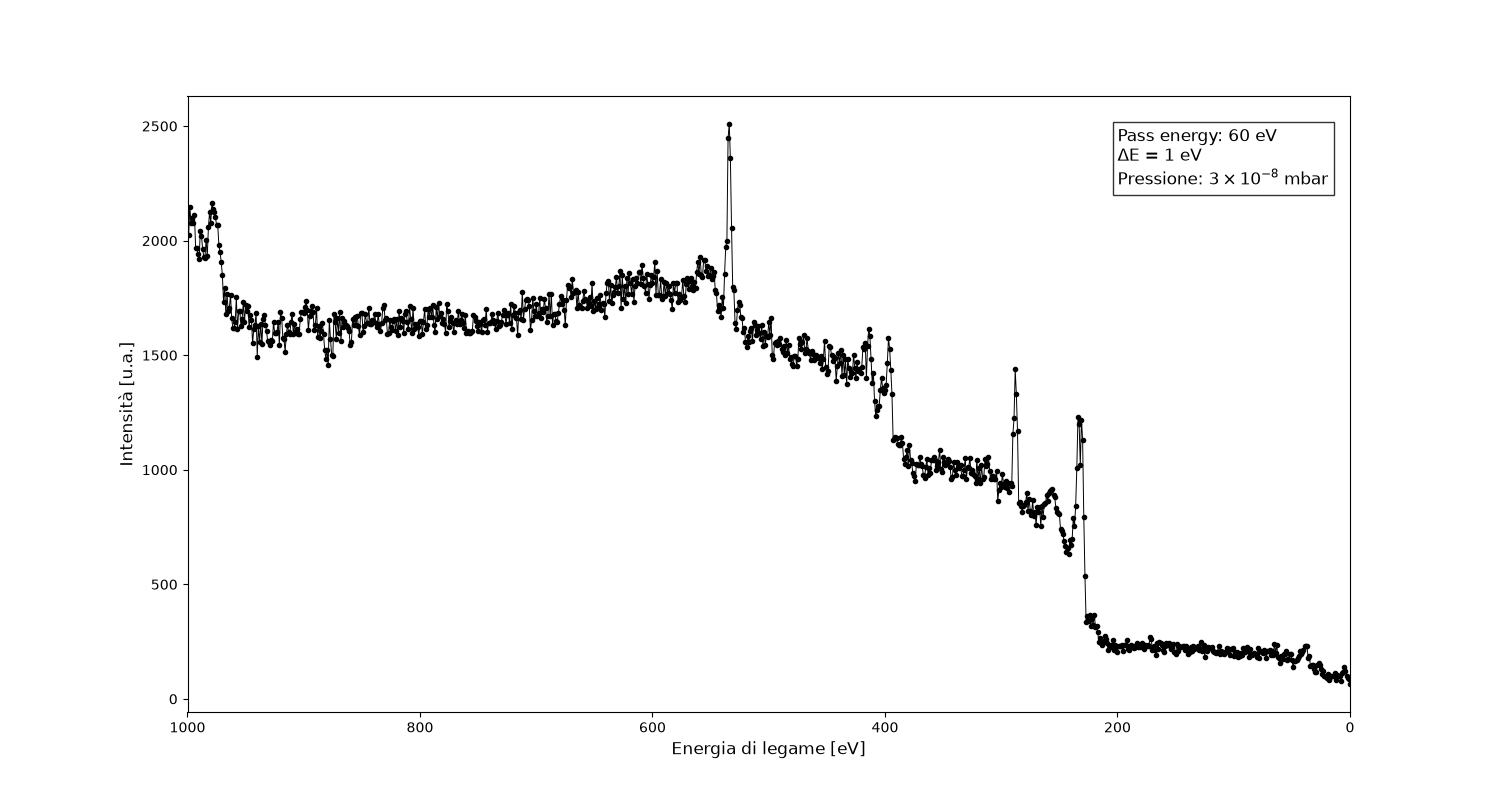

In [16]:
Au_survey = spectra[3]
photon_energy = 1486.6  # Al Kα
Au_survey['BE_eV'] = photon_energy - Au_survey['KE_eV']

fig, ax = plt.subplots(figsize=(15, 8))
ax.plot(Au_survey['BE_eV'], Au_survey['hits_counts'], color='black', linewidth=0.7, marker='.')
ax.set_xlabel('Energia di legame [eV]', fontsize=12)
ax.set_ylabel('Intensità [u.a.]', fontsize=12)
ax.set_xlim(Au_survey['BE_eV'].max(), Au_survey['BE_eV'].min())
ax.text(0.8, 0.95, 
                f'Pass energy: 60 eV \n' + r'$\Delta$E = 1 eV' + '\n' + r'Pressione: $3 \times 10^{-8}$ mbar',
                transform=ax.transAxes,
                fontsize=12,
                verticalalignment='top',
                horizontalalignment='left',
                bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', alpha=0.8))
fig.savefig(fig_path / f'{files[i]}_presentazione.png', dpi=300, bbox_inches='tight')
plt.show()